In [2]:
import pandas as pd
import sys
import numpy as np
from typing import Tuple, List
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/student_depression_dataset.csv")
df.head(200)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,947,Male,33.0,Kanpur,Student,2.0,0.0,9.54,3.0,0.0,'7-8 hours',Healthy,MA,No,11.0,4.0,Yes,0
196,949,Female,20.0,Pune,Student,5.0,0.0,6.17,2.0,0.0,'More than 8 hours',Healthy,'Class 12',Yes,7.0,5.0,Yes,1
197,953,Female,25.0,Agra,Student,2.0,0.0,9.95,1.0,0.0,'More than 8 hours',Unhealthy,B.Pharm,Yes,10.0,5.0,No,1
198,955,Male,24.0,Hyderabad,Student,5.0,0.0,9.05,2.0,0.0,'7-8 hours',Healthy,B.Tech,Yes,8.0,4.0,Yes,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [4]:
#Encode data dạng categorial sang numeral
encode = LabelEncoder()
df_categorical =[]
for column in df.columns:
    if df[column].dtypes=="object":
        df_categorical.append(column)
for column in df_categorical:
    df[column] = encode.fit_transform(df[column])
# Drop các cột không cần thiết
x = df.drop(columns=["Depression", "id", "Profession", "City"])
y =df["Depression"]

In [10]:
x.head()

,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,1,33.0,5.0,0.0,8.97,2.0,0.0,0,0,4,1,3.0,0,0
1,0,24.0,2.0,0.0,5.90,5.0,0.0,0,1,11,0,3.0,1,1
2,1,31.0,3.0,0.0,7.03,5.0,0.0,2,0,6,0,9.0,0,1
3,0,28.0,3.0,0.0,5.59,2.0,0.0,1,1,8,1,4.0,4,1
4,0,25.0,4.0,0.0,8.13,3.0,0.0,0,1,17,1,1.0,0,0


In [6]:
#Slit DATA
X = x.values.astype(float)
y = y.astype(int)   # KHÔNG dùng y.values nữa


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# ép về numpy
y_train = np.array(y_train)
y_test = np.array(y_test)


Test accuracy: 0.8382010392
Sample 0: true=0, pred=0
Sample 1: true=0, pred=0
Sample 2: true=0, pred=0
Sample 3: true=1, pred=1
Sample 4: true=1, pred=0
Sample 5: true=1, pred=1
Sample 6: true=1, pred=1
Sample 7: true=1, pred=1
Sample 8: true=0, pred=0
Sample 9: true=1, pred=1


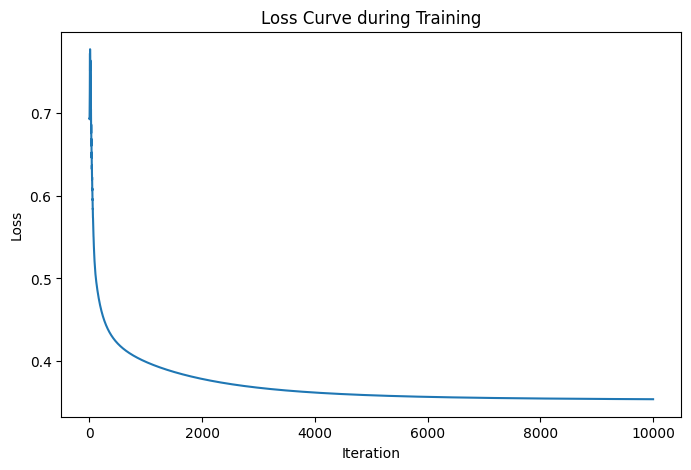

In [ ]:
import matplotlib.pyplot as plt

# =========================
# Logistic Regression từ scratch
# =========================
class LogisticRegressionScratch:
    """Simple binary logistic regression via batch gradient descent."""
    def __init__(self, learning_rate: float = 0.01, n_iters: int = 500):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.weights: np.ndarray | None = None
        self.bias: float = 0.0

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """Train using gradient descent on binary cross-entropy loss."""
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.losses = []

        for _ in range(self.n_iters):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(linear_model)

            # Gradient descent
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Tính loss để visualize
            loss = -np.mean(y*np.log(y_pred + 1e-9) + (1-y)*np.log(1-y_pred + 1e-9))
            self.losses.append(loss)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return (self.predict_proba(X) >= 0.5).astype(int)

    def plot_loss(self):
        plt.figure(figsize=(8,5))
        plt.plot(self.losses)
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Loss Curve during Training")
        plt.show()

# =========================
# Train model
# =========================
model = LogisticRegressionScratch(learning_rate=0.01, n_iters=10000)
model.fit(X_train, y_train)

# =========================
# Evaluate
# =========================
y_pred = model.predict(X_test)
accuracy = (y_pred == y_test).mean()
print(f"Test accuracy: {accuracy:.10f}")

# Sample predictions
for i in range(10):
    print(f"Sample {i}: true={y_test[i]}, pred={y_pred[i]}")

# =========================
# Visualize Loss Curve
# =========================
model.plot_loss()

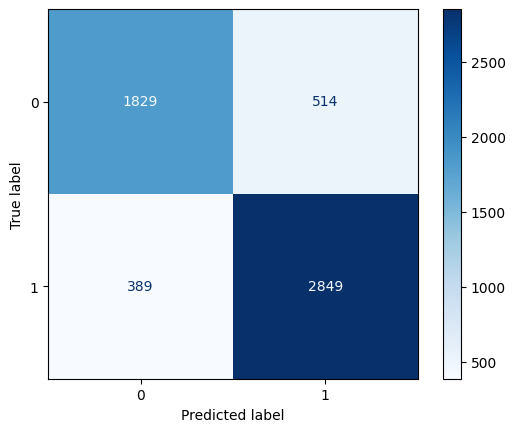

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = model.predict(X_test)  # dự đoán trên X_test
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()


In [ ]:
import ipywidgets as widgets
from IPython.display import display
import numpy as np

# Tạo widget cho từng feature
features = ['Gender', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Degree',
            'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 
            'Dietary Habits', 'Health Condition', 'Financial Stress', 
            'Family History', 'Suicidal Thoughts']

boxes = [widgets.FloatText(description=f) for f in features]

button = widgets.Button(description="Dự đoán")
output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output()  # xoá kết quả cũ
        user_input = [box.value for box in boxes]
        X_new = np.array(user_input).reshape(1, -1)
        y_pred = model.predict(X_new)
        y_prob = model.predict_proba(X_new)
        print("👉 Dự đoán Depression:", int(y_pred[0]))
        print("👉 Xác suất:", y_prob[0])

button.on_click(on_button_clicked)

for box in boxes:
    display(box)
display(button, output)


FloatText(value=0.0, description='Gender')

FloatText(value=0.0, description='Age')

FloatText(value=0.0, description='Academic Pressure')

FloatText(value=0.0, description='Work Pressure')

FloatText(value=0.0, description='CGPA')

...

FloatText(value=0.0, description='Financial Stress')

FloatText(value=0.0, description='Family History')

FloatText(value=0.0, description='Suicidal Thoughts')

Button(description='Dự đoán', style=ButtonStyle())

Output()